# Run standard spatial transcriptomic analyses

Evaluate molecular recovery across 135 held-out ST slides, run five standard downstream analyses and inspect representative spatial readouts.

## Installation

Create a Python 3.10+ environment, install the public HistAgent package and add
the lightweight analysis dependencies used by these notebooks.

```bash
git clone https://github.com/zipging/HistAgent.git
cd HistAgent
python -m venv .venv
source .venv/bin/activate
python -m pip install -e .
python -m pip install jupyter numpy pandas matplotlib seaborn scipy scikit-learn torch huggingface-hub
```

If `data/` is absent, the notebook downloads its data from
`wli13/HistAgent-data`. These examples run without a GPU. Running HistAgent on
new images requires access to the gated Prov-GigaPath model and an authenticated
Hugging Face session.

## Setup

Import the analysis packages, locate the tutorial data and set the plotting style.

In [1]:
from pathlib import Path
import json
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

configured_data = os.getenv("HISTAGENT_TUTORIAL_DATA", "").strip()
DATA_DIR = Path(configured_data).expanduser() if configured_data else Path("data")
if not DATA_DIR.exists():
    from huggingface_hub import snapshot_download

    snapshot = Path(
        snapshot_download(
            "wli13/HistAgent-data",
            repo_type="dataset",
            allow_patterns=["tutorials/**", "manifest.json"],
        )
    )
    DATA_DIR = snapshot / "tutorials"
assert DATA_DIR.exists(), f"Tutorial data not found: {DATA_DIR}"

def rankridge_pack_root(groups):
    configured = os.getenv("HISTAGENT_RANKRIDGE_PACKS", "").strip()
    if configured:
        root = Path(configured).expanduser()
        if not (root / groups[0]).exists():
            root = root / "rankridge_tutorial_packs"
        assert (root / groups[0]).exists(), f"RankRidge pack not found: {root}"
        return root

    from huggingface_hub import snapshot_download

    snapshot = Path(
        snapshot_download(
            "wli13/HistAgent-data",
            repo_type="dataset",
            allow_patterns=[
                f"rankridge_tutorial_packs/{group}/**" for group in groups
            ],
        )
    )
    return snapshot / "rankridge_tutorial_packs"

sns.set_theme(style="white", context="talk")
plt.rcParams.update({
    "figure.dpi": 135,
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.edgecolor": "#000000",
    "axes.labelcolor": "#000000",
    "axes.linewidth": 1.25,
    "axes.grid": False,
    "xtick.color": "#000000",
    "ytick.color": "#000000",
    "text.color": "#000000",
    "font.size": 10,
    "axes.titlesize": 12,
    "axes.labelsize": 10.5,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 9,
    "figure.titlesize": 12,
})
COLORS = {
    "HistAgent": "#168267",
    "Measured ST": "#6f7477",
    "STPath": "#cb77a0",
    "OmiCLIP": "#69aec7",
}
SURVIVAL_COLORS = {"High risk": "#ef4545", "Low risk": "#45b3c2"}
REGION_COLORS = {
    "Poor": "#d85f6b",
    "High": "#79a9d1",
    "Negative": "#b7b7b7",
    "Tumor": "#e32925",
    "Stroma": "#62acec",
}
TASK_CMAPS = {
    "svg": "YlGnBu",
    "domain": "tab10",
    "deconv": "Greens",
    "deg": "Purples",
    "pathway": "PuBuGn",
}

## Overview

The benchmark covers five standard ST analyses across 135 held-out slides. The examples pair measured ST with HistAgent fields.

In [2]:
from scipy.stats import spearmanr
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score

rank = pd.read_json(DATA_DIR / "fig3b.json")
tasks = pd.read_json(DATA_DIR / "fig3c.json")
arrays = np.load(DATA_DIR / "figure3_examples.npz")
meta = json.loads((DATA_DIR / "figure3_examples.json").read_text())

task_cols = ["svg", "domain_ari", "domain_nmi", "deconv", "deg", "pathway"]
tasks[task_cols] = tasks[task_cols].apply(pd.to_numeric, errors="coerce")

print(f"Sections in ranking benchmark: {rank['section'].nunique()}")
print(f"Species: {', '.join(sorted(rank['species'].unique()))}")
print(f"Organs: {rank['organ'].nunique()}")

Sections in ranking benchmark: 135
Species: human, mouse
Organs: 13


## Spot-level gene-ranking recovery

The benchmark reports HitRate@50 and mAP@50 for each section. The table below recomputes method-level summaries from the 405 section and method rows.

In [3]:
rank_display = rank.rename(columns={
    "hit_rate_top50": "HitRate@50",
    "ap_top50": "mAP@50",
})
rank_summary = (
    rank_display.groupby("method")[["HitRate@50", "mAP@50"]]
    .agg(["mean", "median"])
    .sort_values(("mAP@50", "mean"), ascending=False)
)
rank_summary.round(3)

HitRate@50        mAP@50       
                mean median   mean median
method                                   
HistAgent      0.699  0.720  0.655  0.675
OmiCLIP        0.410  0.425  0.311  0.313
STPath         0.292  0.273  0.167  0.135

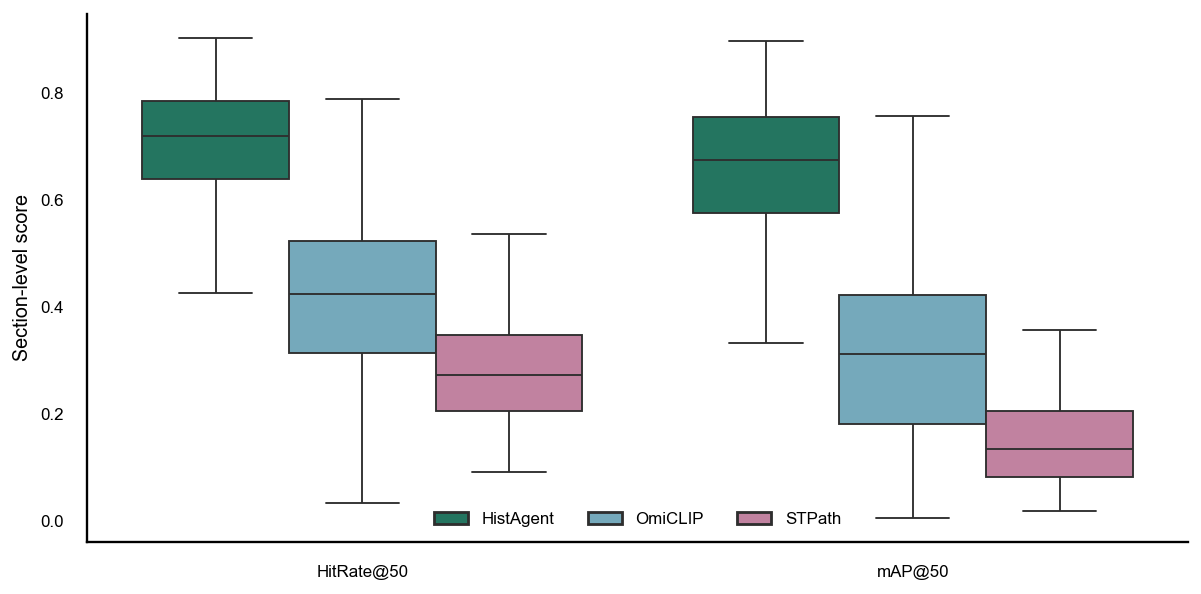

In [4]:
rank_long = rank_display.melt(
    id_vars=["section", "species", "organ", "method"],
    value_vars=["HitRate@50", "mAP@50"],
    var_name="metric", value_name="score"
)
plt.figure(figsize=(9, 4.5))
sns.boxplot(data=rank_long, x="metric", y="score", hue="method",
            palette=COLORS, showfliers=False)
plt.xlabel("")
plt.ylabel("Section-level score")
plt.legend(title="", frameon=False, ncol=3)
plt.tight_layout()
plt.show()

## Five standard spatial transcriptomic analyses

The paper reports six metrics across five analyses: spatially variable genes, spatial domains, cell-type deconvolution, differential expression and pathway enrichment. Four slides are then used to show representative spatial outputs.

In [5]:
task_labels = {
    "svg": "Moran's I Spearman",
    "domain_ari": "Domain ARI",
    "domain_nmi": "Domain NMI",
    "deconv": "Spot Spearman",
    "deg": "DE Spearman",
    "pathway": "nDCG",
}
task_summary = (
    tasks.groupby("method")[task_cols]
    .mean()
    .rename(columns=task_labels)
    .sort_values("nDCG", ascending=False)
)
task_summary.round(3)

,Moran's I Spearman,Domain ARI,Domain NMI,Spot Spearman,DE Spearman,nDCG
method,,,,,,
HistAgent,0.557,0.332,0.409,0.834,0.373,0.840
OmiCLIP,0.253,0.161,0.227,0.645,0.077,0.644
STPath,0.269,0.190,0.258,0.504,0.111,0.492


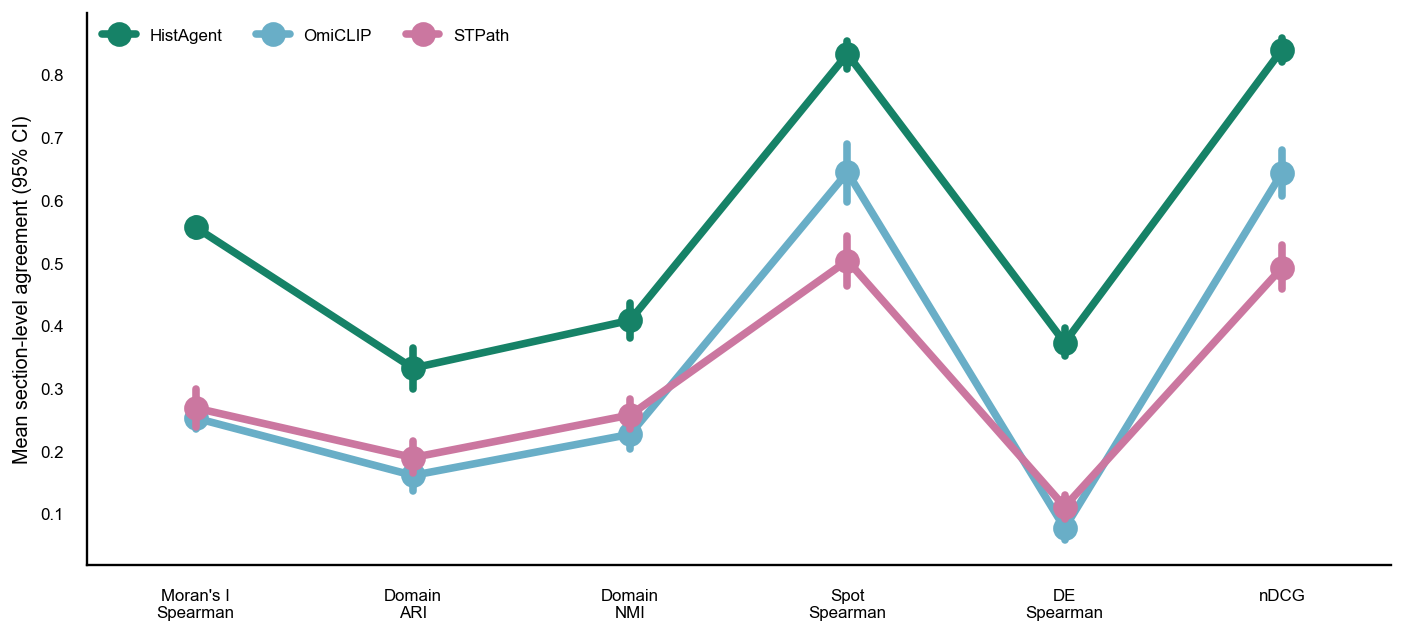

In [6]:
task_long = tasks.melt(
    id_vars=["section", "species", "organ", "method"],
    value_vars=task_cols,
    var_name="task",
    value_name="value",
)
task_long["task"] = task_long["task"].map(task_labels)
plt.figure(figsize=(10.5, 4.8))
sns.pointplot(
    data=task_long, x="task", y="value", hue="method",
    palette=COLORS, estimator="mean", errorbar=("ci", 95),
    seed=17, markers="o",
)
plt.xlabel("")
plt.ylabel("Mean section-level agreement (95% CI)")
plt.xticks(
    ticks=range(6),
    labels=[
        "Moran's I\nSpearman", "Domain\nARI", "Domain\nNMI",
        "Spot\nSpearman", "DE\nSpearman", "nDCG",
    ],
)
plt.legend(title="", frameon=False, ncol=3)
plt.tight_layout()
plt.show()

## Calculate representative spatial readouts

Continuous tasks use Spearman correlation. Domain recovery uses ARI and NMI. The calculations below run on the spot-level arrays before anything is plotted.

In [7]:
records = []
for row in meta["rows"]:
    section = row["section"]
    for task in meta["task_order"]:
        measured = arrays[f"{section}__{task}__measured"]
        predicted = arrays[f"{section}__{task}__predicted"]
        if task == "domain":
            records.append({
                "section": section, "tissue": row["organ"], "task": task,
                "feature": "domain labels",
                "score": adjusted_rand_score(measured, predicted),
                "secondary": normalized_mutual_info_score(measured, predicted),
                "metric": "ARI / NMI",
            })
        else:
            records.append({
                "section": section, "tissue": row["organ"], "task": task,
                "feature": row["features"][task],
                "score": spearmanr(measured, predicted, nan_policy="omit").statistic,
                "secondary": np.nan,
                "metric": "Spearman rho",
            })

example_scores = pd.DataFrame(records)

## Representative outputs across five ST analyses

For each analysis, the measured ST result is shown beside the result calculated from the HistAgent-inferred molecular profile.

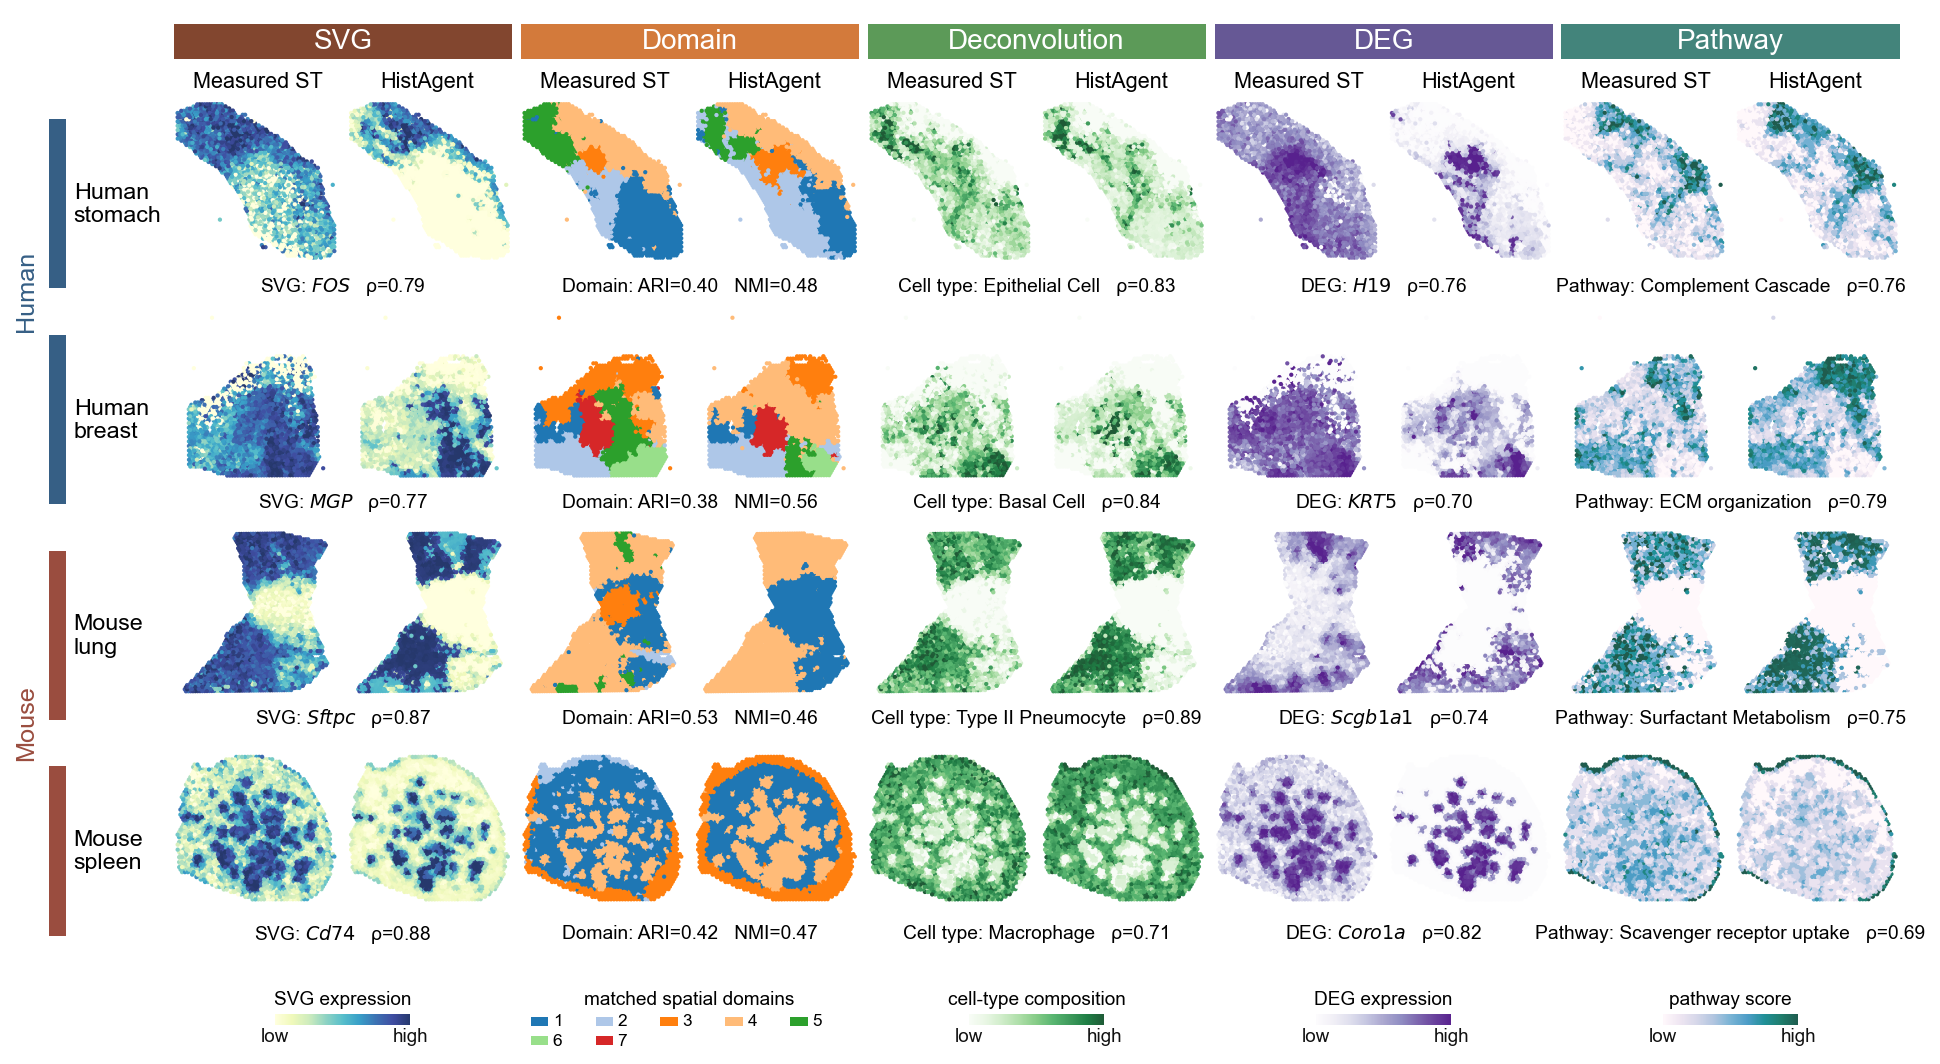

In [8]:
from matplotlib.colorbar import ColorbarBase
from matplotlib.colors import ListedColormap, LinearSegmentedColormap, Normalize
from matplotlib.patches import Rectangle

task_order = meta["task_order"]
task_titles = {
    "svg": "SVG",
    "domain": "Domain",
    "deconv": "Deconvolution",
    "deg": "DEG",
    "pathway": "Pathway",
}
task_colors = {
    "svg": "#82462F",
    "domain": "#D37A3B",
    "deconv": "#5C9A58",
    "deg": "#665895",
    "pathway": "#43847B",
}
species_colors = {"human": "#365F85", "mouse": "#9A4D3F"}
domain_colors = list(plt.get_cmap("tab20").colors[:7])
domain_cmap = ListedColormap(domain_colors)

def percentile_display(values):
    values = np.asarray(values, dtype=float)
    finite = np.isfinite(values)
    if not finite.any() or np.nanstd(values) <= 1e-12:
        return np.zeros_like(values)
    low, high = np.nanpercentile(values, [2, 98])
    if high <= low:
        low, high = np.nanmin(values), np.nanmax(values)
    return np.clip((values - low) / (high - low), 0, 1)

def light_tinted_cmap(name, amount=.12):
    colors = plt.get_cmap(name)(np.linspace(0, 1, 256))
    colors[:, :3] = amount + (1 - amount) * colors[:, :3]
    return LinearSegmentedColormap.from_list(f"{name}_paper", colors)

task_cmaps = {
    "svg": light_tinted_cmap("YlGnBu"),
    "deconv": light_tinted_cmap("Greens"),
    "deg": light_tinted_cmap("Purples", .13),
    "pathway": light_tinted_cmap("PuBuGn"),
}

def plot_spatial_field(ax, coords, values, task):
    x, y = coords[:, 0], coords[:, 1]
    x_pad = max((x.max() - x.min()) * .025, 1)
    y_pad = max((y.max() - y.min()) * .025, 1)
    ax.scatter(
        x, y, c=values, s=4.2,
        cmap=domain_cmap if task == "domain" else task_cmaps[task],
        vmin=-.5 if task == "domain" else 0,
        vmax=6.5 if task == "domain" else 1,
        marker="o", linewidths=0, rasterized=True,
    )
    ax.set_xlim(x.min() - x_pad, x.max() + x_pad)
    ax.set_ylim(y.max() + y_pad, y.min() - y_pad)
    ax.set_aspect("equal", adjustable="box")
    ax.set_axis_off()

fig = plt.figure(figsize=(13.2, 7.3), dpi=150, facecolor="white")
grid = fig.add_gridspec(
    nrows=1 + 2 * len(meta["rows"]) + 1,
    ncols=11,
    width_ratios=[0.78] + [1, 1] * 5,
    height_ratios=[.48] + [1, .25] * len(meta["rows"]) + [.28],
    left=.052, right=.993, top=.962, bottom=.055,
    wspace=.055, hspace=.045,
)

header_axes = {}
for task_i, task in enumerate(task_order):
    header = fig.add_subplot(grid[0, 1 + 2 * task_i:3 + 2 * task_i])
    header_axes[task] = header
    header.set_axis_off()
    header.add_patch(Rectangle(
        (0, .44), 1, .44, transform=header.transAxes,
        facecolor=task_colors[task], edgecolor="none",
    ))
    header.text(.5, .66, task_titles[task], color="white",
                ha="center", va="center", fontsize=13.4)
    header.text(.25, .16, "Measured ST", ha="center", va="center", fontsize=10.4)
    header.text(.75, .16, "HistAgent", ha="center", va="center", fontsize=10.4)

scores_by_section = example_scores.set_index(["section", "task"])
for row_i, row in enumerate(meta["rows"]):
    map_row = 1 + 2 * row_i
    note_row = map_row + 1
    section = row["section"]
    xy = arrays[f"{section}__coords"]
    tissue_ax = fig.add_subplot(grid[map_row:note_row + 1, 0])
    tissue_ax.set_axis_off()
    species_color = species_colors[row["species"]]
    tissue_ax.add_patch(Rectangle(
        (.10, .10), .13, .80, transform=tissue_ax.transAxes,
        facecolor=species_color, edgecolor="none",
    ))
    tissue_ax.text(.29, .5, f"{row['species'].title()}\n{row['organ']}",
                   ha="left", va="center", fontsize=11.2)

    for task_i, task in enumerate(task_order):
        feature = row["features"][task]
        for side, source in enumerate(["measured", "predicted"]):
            values = arrays[f"{section}__{task}__{source}"]
            display_values = (
                values if task == "domain" else percentile_display(values)
            )
            ax = fig.add_subplot(grid[map_row, 1 + 2 * task_i + side])
            plot_spatial_field(ax, xy, display_values, task)

        score = scores_by_section.loc[(section, task)]
        if task == "domain":
            note = (
                f"Domain: ARI={score['score']:.2f}   "
                f"NMI={score['secondary']:.2f}"
            )
        else:
            feature_label = (
                rf"$\mathit{{{feature}}}$"
                if task in {"svg", "deg"} else feature
            )
            prefix = {
                "svg": "SVG",
                "deconv": "Cell type",
                "deg": "DEG",
                "pathway": "Pathway",
            }[task]
            note = f"{prefix}: {feature_label}   ρ={score['score']:.2f}"
        note_ax = fig.add_subplot(
            grid[note_row, 1 + 2 * task_i:3 + 2 * task_i]
        )
        note_ax.set_axis_off()
        note_ax.text(.5, .56, note, ha="center", va="center", fontsize=9.2)

fig.text(.047, .710, "Human", rotation=90, ha="center", va="center",
         fontsize=12.1, color=species_colors["human"])
fig.text(.047, .315, "Mouse", rotation=90, ha="center", va="center",
         fontsize=12.1, color=species_colors["mouse"])

legend_labels = {
    "svg": "SVG expression",
    "deconv": "cell-type composition",
    "deg": "DEG expression",
    "pathway": "pathway score",
}
for task, header in header_axes.items():
    position = header.get_position()
    if task == "domain":
        fig.text(
            position.x0 + .5 * position.width, .054,
            "matched spatial domains", ha="center", va="bottom", fontsize=9.1,
        )
        legend_ax = fig.add_axes([
            position.x0 + .02 * position.width, .017,
            .96 * position.width, .038,
        ])
        legend_ax.set_axis_off()
        for index, color in enumerate(domain_colors):
            col = index % 5
            row = index // 5
            x = .01 + col * .20
            y = .10 + (1 - row) * .46
            legend_ax.add_patch(Rectangle(
                (x, y), .055, .22, facecolor=color, edgecolor="none"
            ))
            legend_ax.text(x + .068, y + .11, str(index + 1),
                           ha="left", va="center", fontsize=8.3)
        continue
    fig.text(
        position.x0 + .5 * position.width, .054,
        legend_labels[task], ha="center", va="bottom", fontsize=9.1,
    )
    color_ax = fig.add_axes([
        position.x0 + .30 * position.width, .039,
        .40 * position.width, .010,
    ])
    colorbar = ColorbarBase(
        color_ax, cmap=task_cmaps[task], norm=Normalize(0, 1),
        orientation="horizontal",
    )
    colorbar.outline.set_visible(False)
    colorbar.set_ticks([0, 1])
    colorbar.set_ticklabels(["low", "high"])
    colorbar.ax.tick_params(labelsize=9, length=0, pad=1, colors="#111111")

plt.show()

## Spatial-readout agreement

The table reports the task-specific score for every example above.

In [9]:
display_table = example_scores.copy()
display_table["display"] = display_table.apply(
    lambda r: (
        f"ARI {r['score']:.2f}; NMI {r['secondary']:.2f}"
        if r["task"] == "domain"
        else f"rho {r['score']:.2f}"
    ), axis=1
)
display_table.pivot(index="tissue", columns="task", values="display")[
    task_order
].rename(columns={
    "svg": "SVG",
    "domain": "Spatial domain",
    "deconv": "Deconvolution",
    "deg": "Differential expression",
    "pathway": "Pathway enrichment",
})

task,SVG,Spatial domain,Deconvolution,Differential expression,Pathway enrichment
tissue,,,,,
breast,rho 0.77,ARI 0.38; NMI 0.56,rho 0.84,rho 0.70,rho 0.79
lung,rho 0.87,ARI 0.53; NMI 0.46,rho 0.89,rho 0.74,rho 0.75
spleen,rho 0.88,ARI 0.42; NMI 0.47,rho 0.71,rho 0.82,rho 0.69
stomach,rho 0.79,ARI 0.40; NMI 0.48,rho 0.83,rho 0.76,rho 0.76


## Verify the calculations

In [10]:
assert rank["section"].nunique() == 135
assert tasks["section"].nunique() == 135
assert len(example_scores) == 4 * len(task_order)
assert np.isfinite(example_scores["score"]).all()
assert all(
    len(arrays[f"{row['section']}__coords"])
    == len(arrays[f"{row['section']}__{task}__measured"])
    == len(arrays[f"{row['section']}__{task}__predicted"])
    for row in meta["rows"] for task in task_order
)
print("Checks passed for 135 sections and all 20 representative task fields.")

Checks passed for 135 sections and all 20 representative task fields.


## Continue

Continue to **Clinical prediction** to inspect pretrained visual-omics representations, spatial slide-level predictions and patient-level prognostic risk.